# **"BioGen": Bacteria Toxicity Classifier**

### **The Scenario**
You are a computational biologist at "BioGen," a lab studying harmful bacteria strains. You need to classify bacterial samples as **"Safe"** or **"Toxic"** based on two automated measurements:

1.  **Colony Population:** Measured in **number of cells** (Large integer values, e.g., 50,000).
2.  **Toxin Secretion Level:** Measured in **micrograms** (Tiny decimal values, e.g., 0.5 µg).

You are using a **K-Nearest Neighbors (KNN)** algorithm to flag dangerous samples. However, your algorithm is failing to detect toxic samples, labeling them "Safe" even when their toxin levels are lethally high.

**Your Goal:** Use Feature Engineering and Linear Transformations ($x' = Wx$) to fix the scaling issue so the algorithm "sees" the toxin data.

---

### **The Data Problem**
Here is your training data. Notice the massive difference in scale between the two features.

| Sample ID | Population ($x_1$) | Toxin Level ($x_2$) | Label ($y$) |
| :--- | :--- | :--- | :--- |
| A | 50,000 | 0.1 | Safe |
| B | 50,100 | 0.2 | Safe |
| C | 49,900 | 0.1 | Safe |
| D | 52,000 | 0.1 | Safe |
| E | 50,000 | 0.9 | **Toxic** |
| F | 49,950 | 0.8 | **Toxic** |

**New Unknown Sample X:**
* **Population:** 50,100
* **Toxin Level:** 0.9 (Very High!)

Intuitively, Sample X has high toxin levels like Sample E, so it should be **Toxic**.
However, let's look at the math.

### **Knowledge Check**

**Question 1:** We calculate the Euclidean Distance between Sample X (50100, 0.9) and two neighbors:
* **Neighbor B (Safe):** (50100, 0.2)
* **Neighbor E (Toxic):** (50000, 0.9)

Which statement is true about the distances?

A) Distance to E is smaller because toxin levels match perfectly (0.9 vs 0.9).

B) Distance to B is smaller because the Population difference is 0, whereas the Population difference to E is 100.

C) The distances are exactly equal.

D) Toxin level is the dominant feature.

Answer = (B); The distance to B is smaller, as the population difference is 0 which leads to the distance being 0.7 whereas the distance to E is 100 due to toxin difference being 0. Therefore it is clear that population level is the dominant feature as even minute differences in that quantity lead to toxin effects being neglected.

### **Feature Transformation ($x' = Wx$)**

The Population numbers (thousands) are "drowning out" the Toxin numbers (decimals). We need to normalize this.
We can define a transformation $x' = Wx$ where $W$ is a scaling matrix.

**Question 2:** We want to scale **Population down by 100,000** and scale **Toxin Level up by 10**.
If input $x = \begin{bmatrix} \text{Pop} \\ \text{Toxin} \end{bmatrix}$, select the correct matrix $W$.

A) $W = \begin{bmatrix} 100,000 & 0 \\ 0 & 0.1 \end{bmatrix}$

B) $W = \begin{bmatrix} 0.00001 & 0 \\ 0 & 10 \end{bmatrix}$

C) $W = \begin{bmatrix} 10 & 0 \\ 0 & 0.00001 \end{bmatrix}$

D) $W = \begin{bmatrix} 1 & 1 \\ 0 & 1 \end{bmatrix}$

Answer = (B); as we need to multiply the population by 0.00001 and multiply the toxin count by 10 and need them in that exact position, therefore the other diagonal element must be 0 to avoid any addition to the final result.

### **Normalization Logic**

**Question 3:** Instead of manually guessing weights, a common technique is **Min-Max Normalization** (scaling to range [0, 1]).
Given a feature vector $x$ with minimum value $x_{min}$ and maximum $x_{max}$, which formula achieves this?

A) $x' = \frac{x - \mu}{\sigma}$

B) $x' = \frac{x - x_{min}}{x_{max} - x_{min}}$

C) $x' = x \times W$

D) $x' = \log(x)$

Answer = (B); as first subtracting by min means that the minimum element is down to 0 and the max element is now (max-min) and dividing that by (max-min) means that the max element goes to 1.

### **Code Walkthrough: Visualizing the Shift**
Let's code this to see how the "Nearest Neighbors" change before and after transformation.

We will use scilit-learn's KNN Classifier for this exercise. Feel free to play around and try with Min-Max normalization scaling technique for both features.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

In [13]:
# 1. Setup Data: 2 Classes (Safe vs Toxic)
# Feature 0: Population (High Variance), Feature 1: Toxin (Low Variance)
# Let's generate 20 data points for better visualization
np.random.seed(42)

# Safe Samples: Pop ~50k, Toxin ~0.1
safe_pop = np.random.normal(50000, 200, 10)
safe_tox = np.random.normal(0.1, 0.05, 10)
safe_data = np.column_stack((safe_pop, safe_tox))

# Toxic Samples: Pop ~50k (Same!), Toxin ~0.9
toxic_pop = np.random.normal(45000, 200, 10)
toxic_tox = np.random.normal(0.9, 0.05, 10)
toxic_data = np.column_stack((toxic_pop, toxic_tox))

X_train = np.vstack((safe_data, toxic_data))
y_train = ['Safe']*10 + ['Toxic']*10

In [14]:
# New Unknown Sample X (High Toxin)
X_new = np.array([[50050, 0.85]])

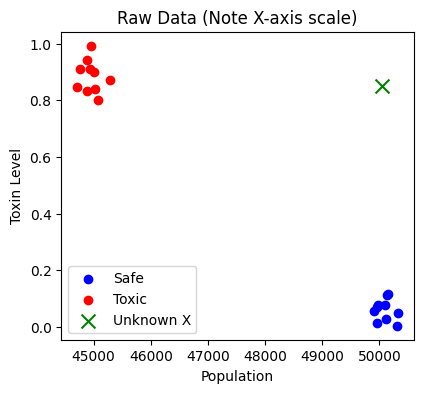

In [15]:
# 2. Visualize RAW Data
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(X_train[:10, 0], X_train[:10, 1], c='blue', label='Safe')
plt.scatter(X_train[10:, 0], X_train[10:, 1], c='red', label='Toxic')
plt.scatter(X_new[:, 0], X_new[:, 1], c='green', marker='x', s=100, label='Unknown X')
plt.title("Raw Data (Note X-axis scale)")
plt.xlabel("Population")
plt.ylabel("Toxin Level")
plt.legend()

In [16]:
# 3. Train KNN on RAW Data
knn_raw = KNeighborsClassifier(n_neighbors=3)
knn_raw.fit(X_train, y_train)
pred_raw = knn_raw.predict(X_new)
print(f"Prediction on RAW Data: {pred_raw[0]}")

Prediction on RAW Data: Safe


In [17]:
# 4. Apply Transformation Matrix W
# Scale Pop by 0.00001, Toxin by 10
W = np.array([
    [0.00001, 0],
    [0,      10]
])

X_transformed = X_train @ W.T
X_new_transformed = X_new @ W.T

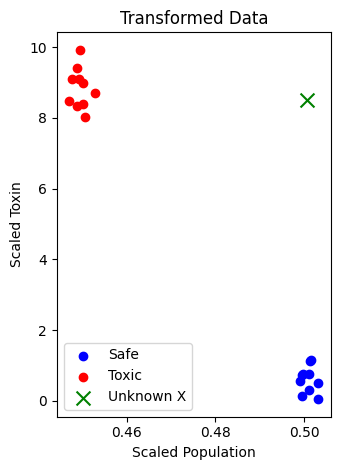

In [18]:
# 5. Visualize Transformed Data
plt.subplot(1, 2, 2)
plt.scatter(X_transformed[:10, 0], X_transformed[:10, 1], c='blue', label='Safe')
plt.scatter(X_transformed[10:, 0], X_transformed[10:, 1], c='red', label='Toxic')
plt.scatter(X_new_transformed[:, 0], X_new_transformed[:, 1], c='green', marker='x', s=100, label='Unknown X')
plt.title("Transformed Data")
plt.xlabel("Scaled Population")
plt.ylabel("Scaled Toxin")
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
# 6. Train KNN on TRANSFORMED Data
knn_trans = KNeighborsClassifier(n_neighbors=3)
knn_trans.fit(X_transformed, y_train)
pred_trans = knn_trans.predict(X_new_transformed)
print(f"Prediction on TRANSFORMED Data: {pred_trans[0]}")

Prediction on TRANSFORMED Data: Toxic


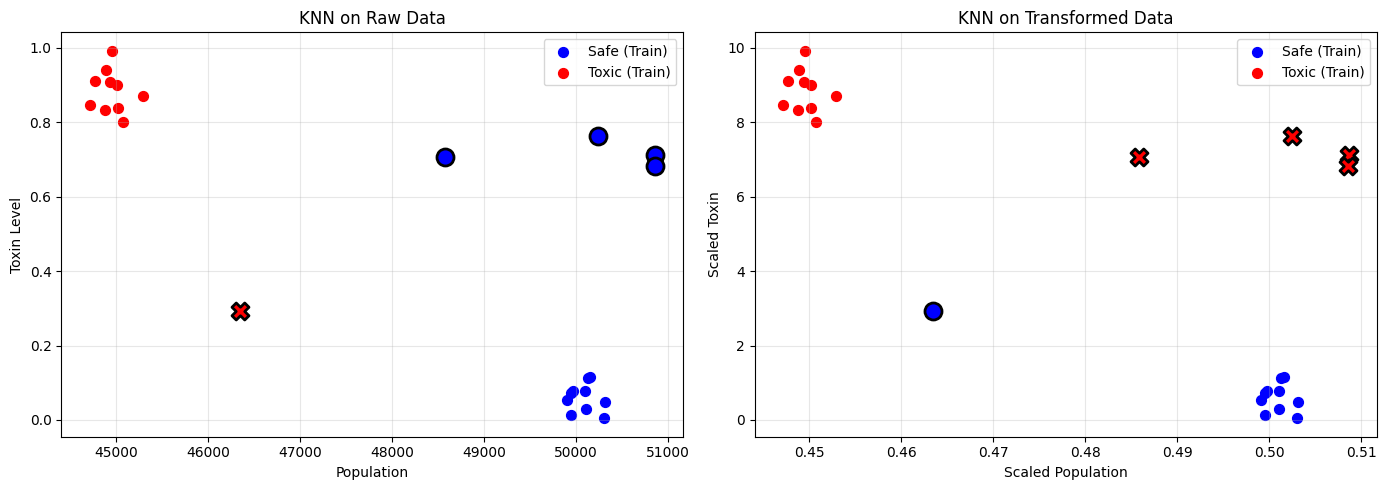


Test Sample Predictions:
Population   Toxin    Raw Pred     Trans Pred  
--------------------------------------------
48582        0.71     Safe         Toxic       
46346        0.29     Toxic        Safe        
50862        0.71     Safe         Toxic       
50243        0.76     Safe         Toxic       
50857        0.68     Safe         Toxic       


In [20]:
np.random.seed(123)
X_test = np.array([
    [np.random.randint(45000, 51000), np.random.uniform(0.1, 0.95)]
    for _ in range(5)
])

X_test_transformed = X_test @ W.T

pred_test_raw = knn_raw.predict(X_test)
pred_test_transformed = knn_trans.predict(X_test_transformed)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_train[:10, 0], X_train[:10, 1], c='blue', label='Safe (Train)', s=50)
axes[0].scatter(X_train[10:, 0], X_train[10:, 1], c='red', label='Toxic (Train)', s=50)
for i, pred in enumerate(pred_test_raw):
    color = 'blue' if pred == 'Safe' else 'red'
    marker = 'o' if pred == 'Safe' else 'X'
    axes[0].scatter(X_test[i, 0], X_test[i, 1], c=color, marker=marker, s=150, edgecolors='black', linewidths=2)
axes[0].set_title("KNN on Raw Data")
axes[0].set_xlabel("Population")
axes[0].set_ylabel("Toxin Level")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(X_transformed[:10, 0], X_transformed[:10, 1], c='blue', label='Safe (Train)', s=50)
axes[1].scatter(X_transformed[10:, 0], X_transformed[10:, 1], c='red', label='Toxic (Train)', s=50)
for i, pred in enumerate(pred_test_transformed):
    color = 'blue' if pred == 'Safe' else 'red'
    marker = 'o' if pred == 'Safe' else 'X'
    axes[1].scatter(X_test_transformed[i, 0], X_test_transformed[i, 1], c=color, marker=marker, s=150, edgecolors='black', linewidths=2)
axes[1].set_title("KNN on Transformed Data")
axes[1].set_xlabel("Scaled Population")
axes[1].set_ylabel("Scaled Toxin")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nTest Sample Predictions:")
print(f"{'Population':<12} {'Toxin':<8} {'Raw Pred':<12} {'Trans Pred':<12}")
print("-" * 44)
for i in range(5):
    print(f"{X_test[i, 0]:<12.0f} {X_test[i, 1]:<8.2f} {pred_test_raw[i]:<12} {pred_test_transformed[i]:<12}")

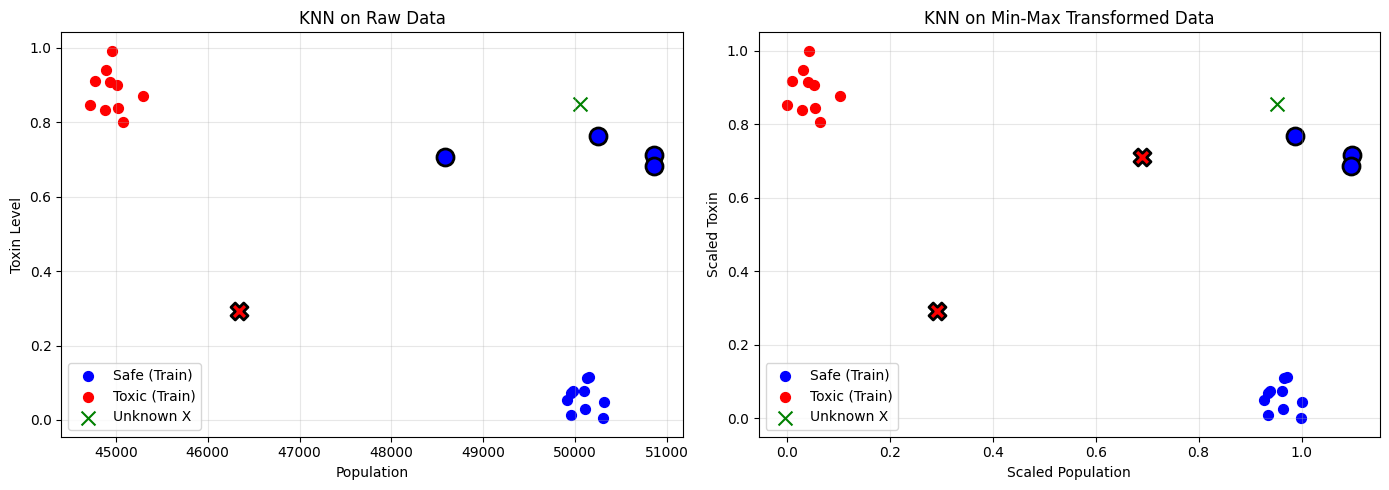


Test Sample Predictions:
Population   Toxin    Raw Pred     MinMax Pred 
----------------------------------------------------
48582        0.71     Safe         Toxic       
46346        0.29     Toxic        Toxic       
50862        0.71     Safe         Safe        
50243        0.76     Safe         Safe        
50857        0.68     Safe         Safe        


In [21]:
# Min-max transform (keep original X_min/X_max untouched by using new names)
X_min_train = X_train.min(axis=0)
X_max_train = X_train.max(axis=0)

X_train_mm = (X_train - X_min_train) / (X_max_train - X_min_train)
X_test_mm = (X_test - X_min_train) / (X_max_train - X_min_train)
X_new_mm = (X_new - X_min_train) / (X_max_train - X_min_train)

# Train KNN on min-max data
knn_minmax = KNeighborsClassifier(n_neighbors=3)
knn_minmax.fit(X_train_mm, y_train)

pred_test_minmax = knn_minmax.predict(X_test_mm)
pred_new_minmax = knn_minmax.predict(X_new_mm)

# Plot raw vs min-max transformed results
fig_mm, axes_mm = plt.subplots(1, 2, figsize=(14, 5))

# Raw data plot
axes_mm[0].scatter(X_train[:10, 0], X_train[:10, 1], c='blue', label='Safe (Train)', s=50)
axes_mm[0].scatter(X_train[10:, 0], X_train[10:, 1], c='red', label='Toxic (Train)', s=50)
for i, p in enumerate(pred_test_raw):
    color = 'blue' if p == 'Safe' else 'red'
    marker = 'o' if p == 'Safe' else 'X'
    axes_mm[0].scatter(X_test[i, 0], X_test[i, 1], c=color, marker=marker, s=150, edgecolors='black', linewidths=2)
axes_mm[0].scatter(X_new[0, 0], X_new[0, 1], c='green', marker='x', s=100, label='Unknown X')
axes_mm[0].set_title("KNN on Raw Data")
axes_mm[0].set_xlabel("Population")
axes_mm[0].set_ylabel("Toxin Level")
axes_mm[0].legend()
axes_mm[0].grid(True, alpha=0.3)

# Min-max transformed plot
axes_mm[1].scatter(X_train_mm[:10, 0], X_train_mm[:10, 1], c='blue', label='Safe (Train)', s=50)
axes_mm[1].scatter(X_train_mm[10:, 0], X_train_mm[10:, 1], c='red', label='Toxic (Train)', s=50)
for i, p in enumerate(pred_test_minmax):
    color = 'blue' if p == 'Safe' else 'red'
    marker = 'o' if p == 'Safe' else 'X'
    axes_mm[1].scatter(X_test_mm[i, 0], X_test_mm[i, 1], c=color, marker=marker, s=150, edgecolors='black', linewidths=2)
axes_mm[1].scatter(X_new_mm[0, 0], X_new_mm[0, 1], c='green', marker='x', s=100, label='Unknown X')
axes_mm[1].set_title("KNN on Min-Max Transformed Data")
axes_mm[1].set_xlabel("Scaled Population")
axes_mm[1].set_ylabel("Scaled Toxin")
axes_mm[1].legend()
axes_mm[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print comparison table
print("\nTest Sample Predictions:")
print(f"{'Population':<12} {'Toxin':<8} {'Raw Pred':<12} {'MinMax Pred':<12}")
print("-" * 52)
for i in range(len(X_test)):
    print(f"{X_test[i, 0]:<12.0f} {X_test[i, 1]:<8.2f} {pred_test_raw[i]:<12} {pred_test_minmax[i]:<12}")